In [2]:
import pandas as pd

In [5]:
df = pd.read_csv('/content/creditcard_fraud.csv')

In [6]:
df.head()

,cardholder_name,card_number,merchant_name,merchant_category,amount,hour,distance_from_home,is_online,is_foreign,velocity_last_hour,is_fraud
0,Allison Hill,4961023726432058,"Merchant: Calhoun, Davis and Richmond",grocery,189.90,6,0.63,1,1,1,0
1,Noah Rhodes,4997245971557937,Merchant: Powell and Sons,online_shopping,14.50,15,1.12,0,0,2,0
2,Angie Henderson,4770115491773269,Merchant: Cox-Mejia,dining,23.46,16,27.38,1,0,0,0
3,Daniel Wagner,4968568888610852,"Merchant: Ortiz, Snow and Garner",grocery,30.00,6,5.75,1,0,0,0
4,Cristian Santos,4358679433644706,Merchant: Barker PLC,grocery,63.56,17,0.42,1,0,1,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cardholder_name     10000 non-null  object 
 1   card_number         10000 non-null  int64  
 2   merchant_name       10000 non-null  object 
 3   merchant_category   10000 non-null  object 
 4   amount              10000 non-null  float64
 5   hour                10000 non-null  int64  
 6   distance_from_home  10000 non-null  float64
 7   is_online           10000 non-null  int64  
 8   is_foreign          10000 non-null  int64  
 9   velocity_last_hour  10000 non-null  int64  
 10  is_fraud            10000 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 859.5+ KB


In [8]:
tracs= df['is_fraud'].value_counts()

In [9]:
tracs

,count
is_fraud,
0,9830
1,170


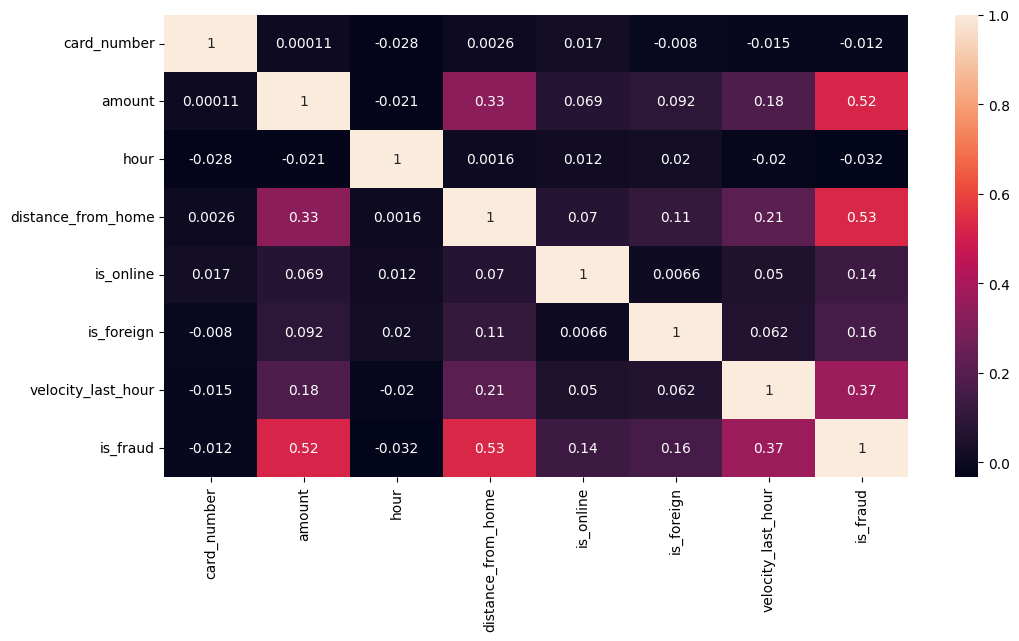

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (12, 6))

cm = df.corr(numeric_only= True)

sns.heatmap(cm, annot= True)

plt.show()

In [12]:
df_ml = df.drop(columns = ['cardholder_name', 'card_number', 'merchant_name'])


In [14]:
df_ml.head()

,merchant_category,amount,hour,distance_from_home,is_online,is_foreign,velocity_last_hour,is_fraud
0,grocery,189.90,6,0.63,1,1,1,0
1,online_shopping,14.50,15,1.12,0,0,2,0
2,dining,23.46,16,27.38,1,0,0,0
3,grocery,30.00,6,5.75,1,0,0,0
4,grocery,63.56,17,0.42,1,0,1,0


In [15]:
df_ml = pd.get_dummies(df_ml, columns = ['merchant_category'], drop_first = True)


In [16]:
df_ml.head()

,amount,hour,distance_from_home,is_online,is_foreign,velocity_last_hour,is_fraud,merchant_category_electronics,merchant_category_gas_station,merchant_category_grocery,merchant_category_online_shopping,merchant_category_travel
0,189.90,6,0.63,1,1,1,0,False,False,True,False,False
1,14.50,15,1.12,0,0,2,0,False,False,False,True,False
2,23.46,16,27.38,1,0,0,0,False,False,False,False,False
3,30.00,6,5.75,1,0,0,0,False,False,True,False,False
4,63.56,17,0.42,1,0,1,0,False,False,True,False,False


In [17]:
X = df_ml.drop(columns = ['is_fraud'])
y = df_ml["is_fraud"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)


In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
model = RandomForestClassifier(n_estimators = 100, random_states = 42, class_weights = 'balanced')

In [21]:
model.fit(X_train, y_train)

RandomForestClassifier()

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn import metrics

In [25]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2949
           1       1.00      0.78      0.88        51

    accuracy                           1.00      3000
   macro avg       1.00      0.89      0.94      3000
weighted avg       1.00      1.00      1.00      3000



In [26]:
import joblib

In [27]:
joblib.dump(model, "credit_card_fraud_detection.pkl")

['credit_card_fraud_detection.pkl']

In [ ]:
model = joblib.load("/content/credit_card_fraud_detection.pkl")